El objetivo de este codigo, es encontrar el valor maximo para la función: 
 - **y=xsin(10*pi*x)+1**

Para lo cual se desarrollaron las clases de **gen** y **poblacion**, con las cuales se desarrolla la exploración de algoritmos geneticos.

In [7]:
!pip install numpy 
!pip install matplotlib

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from gens import *

En el siguiente bloque se define la función a maximizar

In [9]:

def funcion(x): 
    """
    Maximizar la función f(x)=x sen(10πx) + 1, con x ∈[0,1].
    """
    #return x**2 - 1.23*x-6.2
    #return np.cos(10*np.pi*x)*np.sin(x-9.5*np.pi*x)
    return x * np.sin(10 * np.pi * x) + 1


A continuación, se establece el tamaño de la población, el numero de generaciones, y las caracteristicas de sus habitantes, para este caso se usa colecciones de numeros binarios para representar los numeros del 0 al 1

In [10]:

tamano_inicial = 20
generaciones = 100

pb = poblacion(tamano_inicial, 10, 1, "binario", 1, 0)
lista_gen = np.arange(generaciones)
lista_aptitud = []
lista_aptitud_max = []


Posterior a esto, se realiza la evolución de la población, en la cual, se ejecuta un ciclo para el numero de generaciónes en el cual, primero se obtiene el fenotipo del gen, el cual se obtiene de la función **binario_a_entero_rango** la cual convierte la colección en un numero y lo mapea entre un rango especifico (0,1).

El siguiente paso es mapear la aptitud de cada habitante, la cual es directamente la evaluación de la función.

Despues de esto, se genera una nueva población vacia, la cual denominaremos como **población de prueba**, se aplica una función de elitismo, en la cual, se le da un pase gratuito a la siguiente generación a los **2** genes mas aptos, estos elementos pasan a poblar la **población de prueba**, y se ejecuta una función para la selección de los demas elegidos, se cruzan los elementos de la lista y se muta un gen especifico.

Se repite la evaluación de la aptitud con la **población de prueba**, y se evalua si la **población de prueba** posee una aptitud maxima mejor que la generación actual, si es el caso la remplaza en el siguiente ciclo, en caso contrario se asume que es mas apta la población actual. *(Se intento con otro esquema, en el cual se comparaban las aptitudes globales, sin embargo presento mejores resultados la evaluación de la aptitud maxima)*

In [11]:

for i in range(generaciones):
    for i in range(pb.tamano):
        pb.genes[i].fenotipo = binario_a_entero_rango(pb.genes[i], 1, 0)
        pb.genes[i].aptitud = funcion(pb.genes[i].fenotipo)

    sl = pb.elitismo(2)

    sl = pb.seleccion_torneo(seleccionados=sl)
    sl.tamano_inicial = pb.tamano_inicial
    sl.cruce()
    mutante=random.randint(0, sl.tamano-1)
    sl.genes[mutante].mutacion()

    for i in range(sl.tamano):
        sl.genes[i].fenotipo = binario_a_entero_rango(sl.genes[i], 1, 0)
        sl.genes[i].aptitud = funcion(sl.genes[i].fenotipo)
        
    sl.actualizar()
    pb.actualizar()
    #
    #print('AP', round(pb.aptitud_poblacion, 6),
    #      'AS', round(sl.aptitud_poblacion, 6),
    #      'MF', round(pb.mejor_fenotipo, 6),
    #      'AM', max(round(pb.aptitud_maxima, 6), round(sl.aptitud_maxima, 6)))

    if sl.aptitud_maxima > pb.aptitud_maxima:
        print("Nueva poblacion", pb.aptitud_maxima)
        pb = sl
    
    pb.actualizar()
    lista_aptitud.append(pb.aptitud_poblacion)
    lista_aptitud_max.append(pb.aptitud_maxima)

Nueva poblacion 1.8323373287604015
Nueva poblacion 1.8499834204991605


Por ultimo, se grafica la aptitud maxima y global obtenida en cada generación

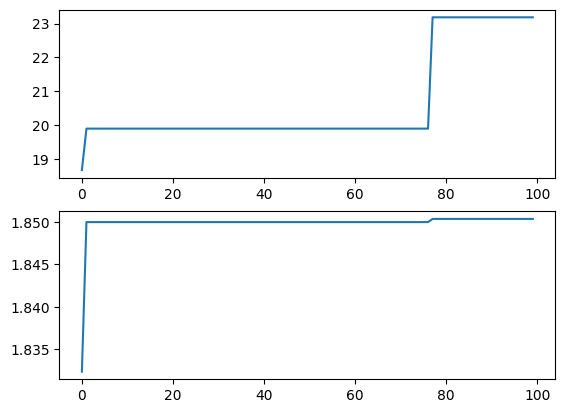

In [13]:
plt.subplot(2,1,1)
plt.plot(lista_gen, lista_aptitud)
plt.subplot(2,1,2)
plt.plot(lista_gen, lista_aptitud_max)
plt.savefig("P1_maximo.png", dpi=300, bbox_inches='tight')
plt.show()
